Determine if reliance behaviors affect academic outcomes. Removing percentage of cautious use to prevent dummy variable trap.

In [1]:
import duckdb
import statsmodels.formula.api as smf
from pathlib import Path

query = """
    WITH student_reliance AS (
        SELECT 
            userId,
            COUNT(*) AS total_interactions,
            SUM(CASE WHEN reliance_category = 'THOUGHTLESS_USE' THEN 1 ELSE 0 END) AS thoughtless_count,
            SUM(CASE WHEN reliance_category = 'REFLECTIVE_USE' THEN 1 ELSE 0 END) AS reflective_count,
            SUM(CASE WHEN reliance_category = 'CAUTIOUS_USE' THEN 1 ELSE 0 END) AS cautious_count
        FROM read_parquet($dataset_path)
        GROUP BY userId
    ), grades_concatenated AS (
        SELECT *, 'f24' AS semester FROM read_csv($fall_sem)
        UNION ALL
        SELECT *, 's25' AS semester FROM read_csv($spring_sem)
    )
    SELECT 
        r.userId,
        r.total_interactions,
        (r.thoughtless_count * 100.0 / r.total_interactions) AS thoughtless_pct,
        (r.reflective_count * 100.0 / r.total_interactions) AS reflective_pct,
        (r.cautious_count * 100.0 / r.total_interactions) AS cautious_pct,
        g.llm AS assignment_avg,
        g.no_llm AS exam_avg,
        g.semester
    FROM student_reliance AS r
    JOIN grades_concatenated AS g 
      ON r.userId = g.userId
"""

with duckdb.connect() as connection:
    df_regression = connection.execute(query, {
        "dataset_path": str(Path("../data/outputs/clean_analytical_dataset.parquet")),
        "fall_sem": str(Path("/workspaces/StudyChat/scores/f24_grades_released_normalized.csv")),
        "spring_sem": str(Path("/workspaces/StudyChat/scores/s25_grades_released_normalized.csv"))
    }).df()

model = smf.ols(
    'exam_avg ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)', data=df_regression)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               exam_avg   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.497
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.205
Time:                        05:20:48   Log-Likelihood:                 173.63
No. Observations:                 175   AIC:                            -337.3
Df Residuals:                     170   BIC:                            -321.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8504      0

Variance inflation factor testing to determine collinearity of reliance percentages. Used since the condition number is affected by the difference in variable scales.

In [2]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

variables = ['thoughtless_pct', 'reflective_pct', 'total_interactions']
X = df_regression[variables].dropna()

X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF_Score"] = [variance_inflation_factor(
    X.values, i) for i in range(X.shape[1])]

print(vif_data)

             Variable  VIF_Score
0               const  57.801242
1     thoughtless_pct   2.641874
2      reflective_pct   2.576705
3  total_interactions   1.053670


Run regression model on assignment average - exam average as dependent variable

In [3]:
df_regression['grade_drop'] = df_regression['assignment_avg'] - df_regression['exam_avg']

model_delta = smf.ols('grade_drop ~ thoughtless_pct + reflective_pct + total_interactions', data=df_regression)
print(model_delta.fit().summary())

                            OLS Regression Results                            
Dep. Variable:             grade_drop   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.2403
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.868
Time:                        05:20:48   Log-Likelihood:                 214.66
No. Observations:                 175   AIC:                            -421.3
Df Residuals:                     171   BIC:                            -408.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.1092      0

K-means clustering to group students into the three reliance groups.

                  thoughtless_pct  reflective_pct  cautious_pct
behavior_profile                                               
0                       81.300908       11.751613      6.947479
1                       28.415732       40.911588     30.672679
2                       48.464630       31.230593     20.304777


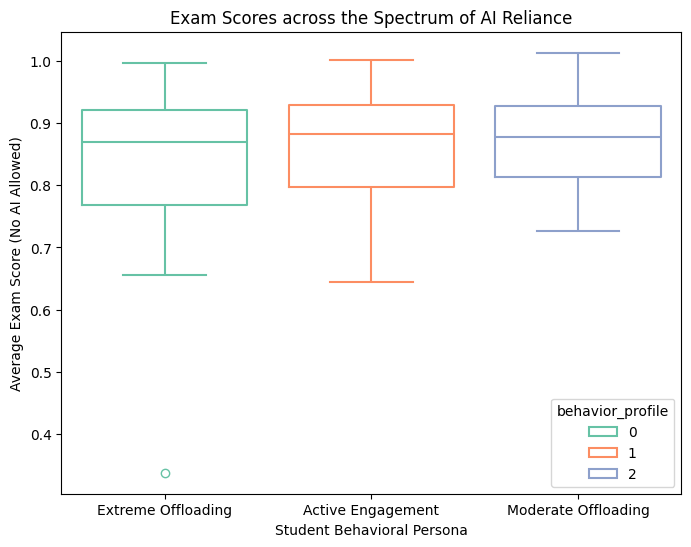

In [7]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

features = df_regression[['thoughtless_pct', 'reflective_pct', 'cautious_pct']]
kmeans = KMeans(n_clusters=3, random_state=42)
df_regression['behavior_profile'] = kmeans.fit_predict(features)

cluster_profiles = df_regression.groupby('behavior_profile')[['thoughtless_pct', 'reflective_pct', 'cautious_pct']].mean()

print(cluster_profiles)

# These need to be remapped based on how the unsupervised learning orders the clusters
# "Balanced" is the group with 28% thoughtless, 40% reflective, and 30% cautious
# "Moderate" is the group with 48% thoughtless, 31% reflective, and 20% cautious
# "Offloaders" is the group with 81% thoughtless
# Approximate values above are rounded down, some variance might occur due to unsupervised learning
cluster_names = {
    0: "Extreme Offloading",
    1: "Active Engagement",
    2: "Moderate Offloading"
}

df_regression['behavior_profile_name'] = df_regression['behavior_profile'].map(cluster_names)

order = ["Extreme Offloading", "Active Engagement", "Moderate Offloading"]

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_regression, x='behavior_profile_name', y='exam_avg', order=order, hue="behavior_profile", fill=False, palette="Set2")
plt.title("Exam Scores across the Spectrum of AI Reliance")
plt.xlabel("Student Behavioral Persona")
plt.ylabel("Average Exam Score (No AI Allowed)")
plt.show()

Checking emergence of reliance indicators across conversation length.

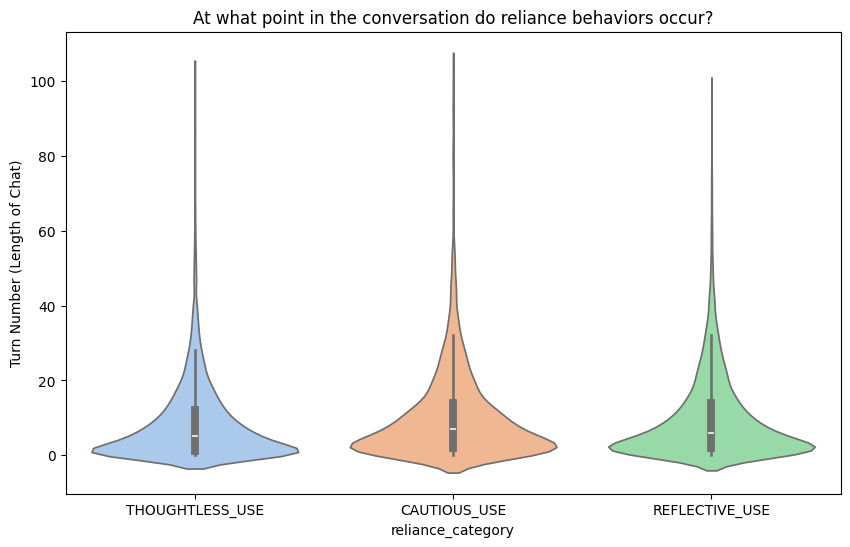

In [5]:
query_length = """
    SELECT reliance_category, interactionCount
    FROM read_parquet($dataset_path)
    WHERE reliance_category IS NOT NULL
"""

with duckdb.connect() as connection:
    df_length = connection.execute(query_length, {
        "dataset_path": str(Path("../data/outputs/clean_analytical_dataset.parquet"))
    }).df()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_length, x='reliance_category',
               y='interactionCount', palette='pastel', hue="reliance_category")
plt.title("At what point in the conversation do reliance behaviors occur?")
plt.ylabel("Turn Number (Length of Chat)")
plt.show()

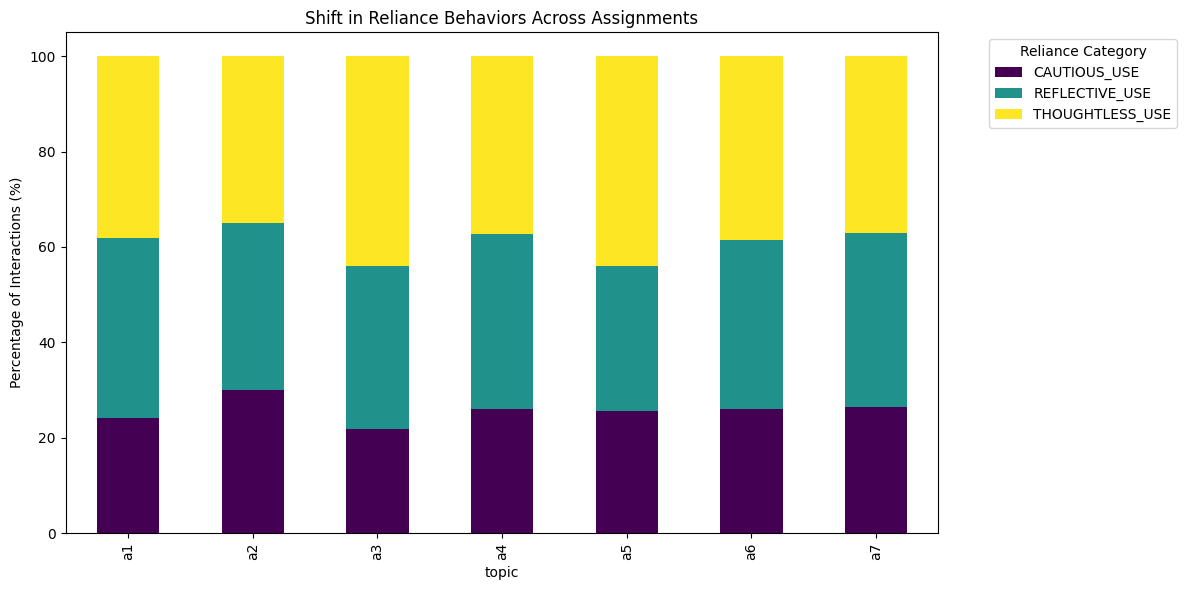

In [6]:
query_topics = """
    SELECT 
        topic,
        reliance_category,
        COUNT(*) as cat_count
    FROM read_parquet($dataset_path)
    WHERE reliance_category IS NOT NULL
    GROUP BY topic, reliance_category
"""

with duckdb.connect() as connection:
    df_topics = connection.execute(query_topics, {
        "dataset_path": str(Path("../data/outputs/clean_analytical_dataset.parquet"))
    }).df()

df_pivot = df_topics.pivot(
    index='topic', columns='reliance_category', values='cat_count').fillna(0)
df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

df_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Shift in Reliance Behaviors Across Assignments")
plt.ylabel("Percentage of Interactions (%)")
plt.legend(title="Reliance Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()